In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'
TEST_YEAR = '2024'
TEST_MONTH = '7'
NUTS2_EL = 'θεσσαλιας'

In [3]:
trained_model = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [4]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_{TEST_YEAR}.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(21, 112)


In [5]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL611,2024,1,21.720538,39.507246,0.349829,0.129800,-0.279926,-0.129800,0.338639,0.125415,-0.269985,-0.125415,0.069714,0.069789,0.072988,0.069789,9.980994,8.442297,9.960925,15.827328,15.827328,4.665845,1.997685,1.196473,5.066013,5.066013,7.323419,5.219991,5.578699,10.446671,10.446671,0.808113,13.043208,1.783729,0.693578,7.213471,46.575779,2132.964332,1147.871069,37.028099,15.333333,17.000000,42.500000,782.865753,36.0,-4.0,40.0,16.333333,25.000000,25.500000,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,14537.0,68346.0,30036.0,112919.0,13491.0,65903.0,35332.0,114726.0,2452.45,6070.0,6292.0,0
1,EL612,2024,1,22.407574,39.702044,0.377971,0.096497,-0.311212,-0.096497,0.369537,0.092635,-0.303914,-0.092635,0.066988,0.070704,0.062049,0.070704,11.755364,10.128541,11.575010,17.263028,17.263028,4.601759,2.436280,1.280138,5.371649,5.371649,8.178562,6.282411,6.427574,11.317338,11.317338,0.583333,15.278100,1.460194,0.092524,4.576956,41.624956,1576.167857,1758.387097,56.722164,17.000000,19.666667,42.753623,871.519050,42.0,-4.0,46.0,18.000000,7.000000,28.333333,7.0,1569.0,857.0,10.0,176.491584,1042.0,100.0,133.0,100.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,20258.0,83984.0,28103.0,132345.0,18771.0,82771.0,34457.0,135999.0,3864.93,2621.0,2977.0,0
2,EL613,2024,1,22.862978,39.279998,0.386385,0.198975,-0.296616,-0.198975,0.386507,0.196429,-0.300579,-0.196429,0.070134,0.067644,0.067993,0.067644,12.334942,10.855230,10.375943,15.684080,15.684080,6.372275,3.980489,3.083387,6.281480,6.281480,9.353608,7.417859,6.729665,10.982780,10.982780,2.669381,16.328144,3.872310,0.752353,7.508872,113.750258,2307.193655,817.948454,26.385434,16.916667,17.500000,42.682927,788.506452,40.0,-1.0,41.0,17.666667,27.166667,27.166667,8.0,2301.0,1319.0,5.0,187.183200,1525.0,88.0,88.0,235.0,31,20,30,12,12,1,1,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,1

In [6]:
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
len(data_test.NUTS3_ID.unique())

3

In [8]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [9]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL611,2024,7,21.720538,39.507246,0.498083,0.149836,-0.449555,-0.149836,0.488936,0.147711,-0.442092,-0.147711,0.053610,0.049539,0.037844,0.049539,30.772386,8.239980,11.270013,15.315817,23.483530,20.085504,2.754859,3.885821,5.499430,10.308722,25.428945,5.497419,7.577917,10.407623,16.896126,17.589811,34.920881,0.0,0.0,0.0,0.0,434.247378,1353.713836,45.123795,15.333333,17.000000,42.500000,782.865753,36.0,-4.0,40.0,16.333333,25.000000,25.500000,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,14537.0,68346.0,30036.0,112919.0,13491.0,65903.0,35332.0,114726.0,2452.45,6070.0,6292.0,0,-0.5,-0.866025
1,EL612,2024,7,22.407574,39.702044,0.356220,0.026639,-0.368806,-0.026639,0.353078,0.027449,-0.366453,-0.027449,0.050763,0.050839,0.033392,0.050839,35.759648,10.064603,13.185553,16.886099,24.998637,20.786099,3.168784,4.355285,6.046111,10.508383,28.272874,6.616693,8.770419,11.466105,17.753510,17.932437,40.192437,0.0,0.0,0.0,0.0,384.646256,1946.476703,64.882557,17.000000,19.666667,42.753623,871.519050,42.0,-4.0,46.0,18.000000,7.000000,28.333333,7.0,1569.0,857.0,10.0,176.491584,1042.0,100.0,133.0,100.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,20258.0,83984.0,28103.0,132345.0,18771.0,82771.0,34457.0,135999.0,3864.93,2621.0,2977.0,0,-0.5,-0.866025
2,EL613,2024,7,22.862978,39.279998,0.442596,0.137075,-0.406889,-0.137075,0.436664,0.134997,-0.403249,-0.134997,0.050704,0.048519,0.035086,0.048519,32.661127,10.133658,12.615667,15.692800,22.897291,21.434785,5.566575,6.373015,7.483881,11.991336,27.047956,7.850116,9.494341,11.588341,17.444313,19.711237,36.305258,0.0,0.0,0.0,0.0,576.885510,537.309278,17.910309,16.916667,17.500000,42.682927,788.506452,40.0,-1.0,41.0,17.666667,27.166667,27.166667,8.0,2301.0,1319.0,5.0,187.183200,1525.0,88.0,88.0,235.0,31,20,30,12,12,1,1,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.2

In [10]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [11]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [12]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [13]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
1,EL612,2024,7,22.407574,39.702044,0.264919
0,EL611,2024,7,21.720538,39.507246,0.096816
2,EL613,2024,7,22.862978,39.279998,0.021919


In [14]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [15]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [16]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL61,Θεσσαλία,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [17]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL611,"Καρδίτσα, Τρίκαλα","POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL612,Λάρισα,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL613,"Μαγνησία, Σποράδες","MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [18]:
greece_lau1.head()

,NAME,geometry
0,Αγιάς,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αλοννήσου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
2,Αλμυρού,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
3,Αργιθέας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
4,Βόλου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [19]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,SMOKOVO RESERVOIR,9917521.0,57610.200,"POLYGON ((22.15620 39.12133, 22.15606 39.12153...",0
1,KARLAS RESERVOIR,34925588.0,29704.895,"POLYGON ((22.78083 39.49649, 22.78114 39.49670...",1
2,TAVROPOS RESERVOIR,23560746.0,85317.960,"POLYGON ((21.69880 39.34183, 21.69943 39.34191...",2


In [20]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [21]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [22]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

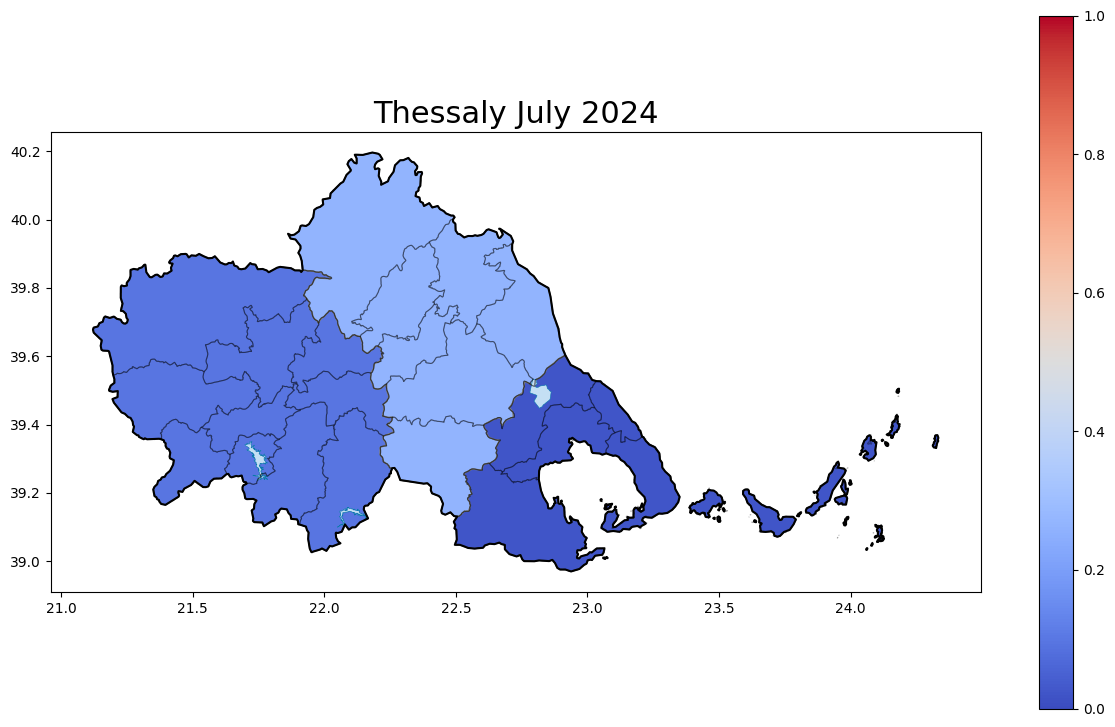

In [23]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [24]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = 'Thessaly July 2024',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=650, size_f5=6.5)

fig.show()

In [25]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL611,2024,7,21.7205,39.5072,0.096816,"Καρδίτσα, Τρίκαλα","POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL612,2024,7,22.4076,39.7020,0.264919,Λάρισα,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL613,2024,7,22.8630,39.2800,0.021919,"Μαγνησία, Σποράδες","MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [26]:
results.to_file(f'../../../data/{NUTS2}/predictions/GR_{NUTS2}_NUTS3_Predictions_June_2024.shp', encoding = 'utf-8')